# Config 1 eTOF spectrum vs photon energy, per GMD bin

Takes a list of config 1 aggregate files — **one file per photon
energy** — each binned on GMD, and builds a 2D map of
GMD-normalised electron TOF spectra against photon energy for every
GMD bin.

Two figures are produced:

1. The normalised spectrum `D / G` (mean eTOF spectrum per shot
   divided by the per-bin mean GMD) plotted as a TOF × energy map,
   one panel per GMD bin.
2. The same map with the lowest-GMD-bin spectrum subtracted at each
   energy (so the lowest GMD panel is identically zero).

In [1]:
import os, sys
from pathlib import Path

os.environ["FLASH_ENV"] = "remote"

In [2]:
import sys
import re
from pathlib import Path

repo_root = Path("/home/mmanresa/glycine26/")

# 2. Safety check to make sure the folder structure is what we expect
scripts_dir = repo_root / "analysis" / "scripts"
if not scripts_dir.exists():
    raise RuntimeError(f"Could not find scripts folder at: {scripts_dir}")

# 3. Add it to Python's path
sys.path.insert(0, str(scripts_dir))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

import config
from compute_aggregates import load_aggregates
%matplotlib inline

## Parameters

Provide a list of `(path, photon_energy_eV)` pairs, or set
`AGG_DIR` + `GLOB` and let the regex pull the energy from each
filename. Each file must be a config 1 spectral aggregate (has `D`,
`G`, `tof_edges`, `gmd_edges`).

In [29]:
# --- Option A: explicit list (path, energy_eV) -----------------------
FILES = None  # e.g. [("runXXX_aggregates.h5", 290.0), ...]

# --- Option B: glob a directory and parse eV from filename ----------
AGG_DIR    = config.COMBINED_DIR
GLOB = "glycine_WL_scan_*eV_aggregates_etof1.h5"

ENERGY_RE = re.compile(
    r"^glycine_WL_scan_(\d+(?:\.\d+)?)eV_aggregates_etof1$"
)

MAX_ENERGY = 279.5

# --- Display / cosmetics -------------------------------------------
TOF_RANGE  = (None, None)   # plot x-limits in TOF units; (None, None) = full
VMIN, VMAX = None, None     # shared colour scale for plot 1; None = auto
DIFF_SYM   = True           # symmetric diverging colormap for plot 2

# --- Discover files ------------------------------------------------
def _energy_from_name(p):
    m = ENERGY_RE.search(Path(p).stem)
    if not m:
        raise ValueError(
            f"could not parse photon energy (looked for '<num>eV') from {p}"
        )
    return float(m.group(1))

if FILES is None:
    paths = sorted(Path(AGG_DIR).glob(GLOB))
    if not paths:
        raise FileNotFoundError(f"no files match {AGG_DIR}/{GLOB}")
    FILES = [(p, _energy_from_name(p)) for p in paths]

FILES = [(p, e) for p, e in FILES if e <= MAX_ENERGY]


def _is_decimal_zero_energy_file(p):
    return re.search(r"_\d+\.0eV_aggregates_etof1\.h5$", Path(p).name) is not None

# For repeated nominal energies, prefer the file written as "279.0eV"
# over the bare "279eV".
dedup = {}
for p, e in FILES:
    old = dedup.get(e)
    if old is None:
        dedup[e] = (p, e)
    elif _is_decimal_zero_energy_file(p):
        dedup[e] = (p, e)

FILES = sorted(dedup.values(), key=lambda pe: pe[1])

print(f"{len(FILES)} aggregate files:")
for p, e in FILES:
    print(f"  {e:>8.2f} eV  {Path(p).name}")

20 aggregate files:
    270.00 eV  glycine_WL_scan_270.0eV_aggregates_etof1.h5
    270.50 eV  glycine_WL_scan_270.5eV_aggregates_etof1.h5
    271.00 eV  glycine_WL_scan_271.0eV_aggregates_etof1.h5
    271.50 eV  glycine_WL_scan_271.5eV_aggregates_etof1.h5
    272.00 eV  glycine_WL_scan_272.0eV_aggregates_etof1.h5
    272.50 eV  glycine_WL_scan_272.5eV_aggregates_etof1.h5
    273.00 eV  glycine_WL_scan_273.0eV_aggregates_etof1.h5
    273.50 eV  glycine_WL_scan_273.5eV_aggregates_etof1.h5
    274.00 eV  glycine_WL_scan_274.0eV_aggregates_etof1.h5
    274.50 eV  glycine_WL_scan_274.5eV_aggregates_etof1.h5
    275.00 eV  glycine_WL_scan_275.0eV_aggregates_etof1.h5
    275.50 eV  glycine_WL_scan_275.5eV_aggregates_etof1.h5
    276.00 eV  glycine_WL_scan_276.0eV_aggregates_etof1.h5
    276.50 eV  glycine_WL_scan_276.5eV_aggregates_etof1.h5
    277.00 eV  glycine_WL_scan_277.0eV_aggregates_etof1.h5
    277.50 eV  glycine_WL_scan_277.5eV_aggregates_etof1.h5
    278.00 eV  glycine_WL_scan_278.0

## Load and stack

Each file contributes one row to a `(n_energies, n_gmd, n_tof)`
stack. The TOF axis and GMD edges must match across files; we check
that explicitly. Per-file normalisation is `D_e / G_e`: the mean
per-shot eTOF spectrum divided by the mean GMD in that GMD bin, so
the units are counts-per-bin per µJ.

In [30]:
energies = np.array([e for _, e in FILES], dtype=np.float64)

stack = None        # (n_E, n_gmd, n_tof) normalised D/G
n_shots = None      # (n_E, n_gmd) shot count per bin
tof_edges = None
gmd_edges = None

for k, (path, e) in enumerate(FILES):
    agg = load_aggregates(path)
    if agg.config != 1:
        raise ValueError(
            f"{Path(path).name}: config={agg.config}, expected 1"
        )
    if agg.mode != "spectral":
        raise ValueError(
            f"{Path(path).name}: mode={agg.mode!r}, expected 'spectral'"
        )
    if tof_edges is None:
        tof_edges = agg.tof_edges
        gmd_edges = agg.gmd_edges
        n_E   = len(FILES)
        n_gmd = agg.n_gmd_bins
        n_tof = agg.n_tof
        stack   = np.full((n_E, n_gmd, n_tof), np.nan, dtype=np.float64)
        n_shots = np.zeros((n_E, n_gmd), dtype=np.int64)
    else:
        if not np.array_equal(agg.tof_edges, tof_edges):
            raise ValueError(
                f"{Path(path).name}: tof_edges mismatch"
            )
        if not np.array_equal(agg.gmd_edges, gmd_edges):
            raise ValueError(
                f"{Path(path).name}: gmd_edges mismatch"
            )

    # D / G per GMD bin; broadcast G along the TOF axis.
    with np.errstate(invalid="ignore", divide="ignore"):
        stack[k] = agg.D / agg.G[:, None]
    n_shots[k] = agg.n_per_bin

tof_cent = 0.5 * (tof_edges[:-1] + tof_edges[1:])
gmd_cent = 0.5 * (gmd_edges[:-1] + gmd_edges[1:])

print(f"stack shape  : {stack.shape}  (n_E, n_gmd, n_tof)")
print(f"GMD bins     : {n_gmd}  edges {gmd_edges}")
print(f"TOF range    : [{tof_edges[0]:.2f}, {tof_edges[-1]:.2f}) in {n_tof} bins")
print(f"energy range : [{energies.min():.2f}, {energies.max():.2f}] eV ({len(energies)} points)")

stack shape  : (20, 4, 5000)  (n_E, n_gmd, n_tof)
GMD bins     : 4  edges [ 0.  3.  6. 12. 24.]
TOF range    : [0.00, 5000.00) in 5000 bins
energy range : [270.00, 279.50] eV (20 points)


## Plot 1 — normalised eTOF spectrum vs energy, per GMD bin

One panel per GMD bin. Shared colour scale by default so absolute
intensities across bins are comparable; set `VMIN`/`VMAX` explicitly
to override.

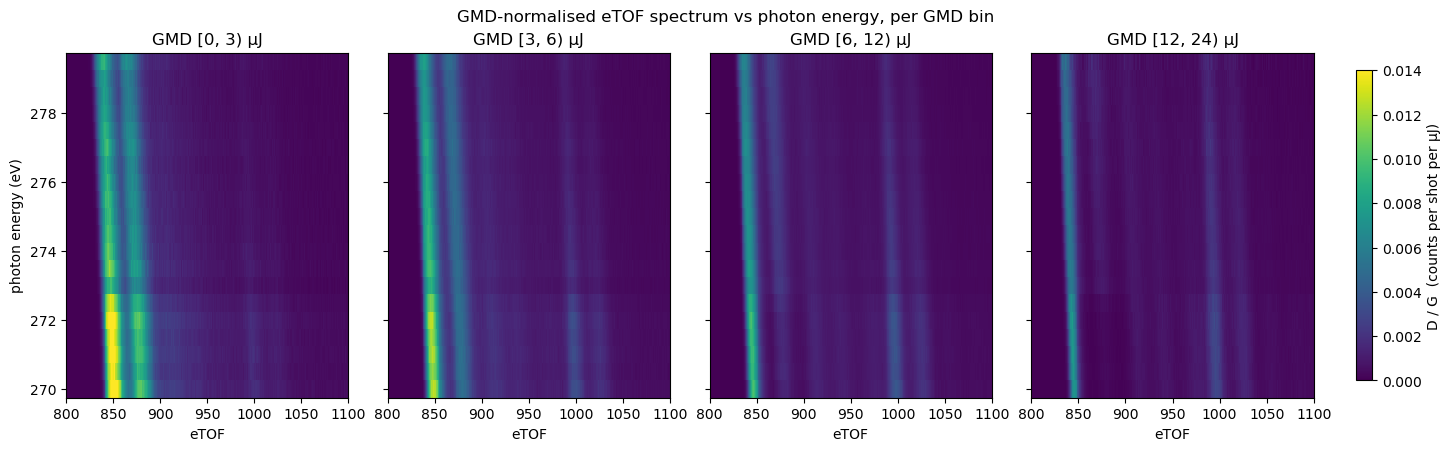

In [31]:
def _energy_edges(e):
    """Half-step edges around a non-uniform energy axis for pcolormesh."""
    e = np.asarray(e, dtype=np.float64)
    mid = 0.5 * (e[:-1] + e[1:])
    return np.concatenate([[2 * e[0] - mid[0]], mid, [2 * e[-1] - mid[-1]]])

e_edges = _energy_edges(energies)

finite = stack[np.isfinite(stack)]
vmin = VMIN if VMIN is not None else float(np.nanpercentile(finite, 1))
vmax = VMAX if VMAX is not None else float(np.nanpercentile(finite, 99))

vmin = 0
vmax = 0.014

fig, axes = plt.subplots(
    1, n_gmd, figsize=(3.6 * n_gmd, 4.4), sharey=True,
    constrained_layout=True,
)
axes = np.atleast_1d(axes)

for g, ax in enumerate(axes):
    pcm = ax.pcolormesh(
        tof_edges, e_edges, stack[:, g, :],
        cmap="viridis", vmin=vmin, vmax=vmax, shading="auto",
    )
    ax.set_title(
        f"GMD [{gmd_edges[g]:.2g}, {gmd_edges[g + 1]:.2g}) µJ"
    )
    ax.set_xlabel("eTOF")
    if TOF_RANGE[0] is not None or TOF_RANGE[1] is not None:
        ax.set_xlim(TOF_RANGE[0], TOF_RANGE[1])
    ax.set_xlim(800,1100)

axes[0].set_ylabel("photon energy (eV)")
cbar = fig.colorbar(pcm, ax=axes, location="right", shrink=0.9, pad=0.02)
cbar.set_label("D / G  (counts per shot per µJ)")
fig.suptitle("GMD-normalised eTOF spectrum vs photon energy, per GMD bin")
plt.show()

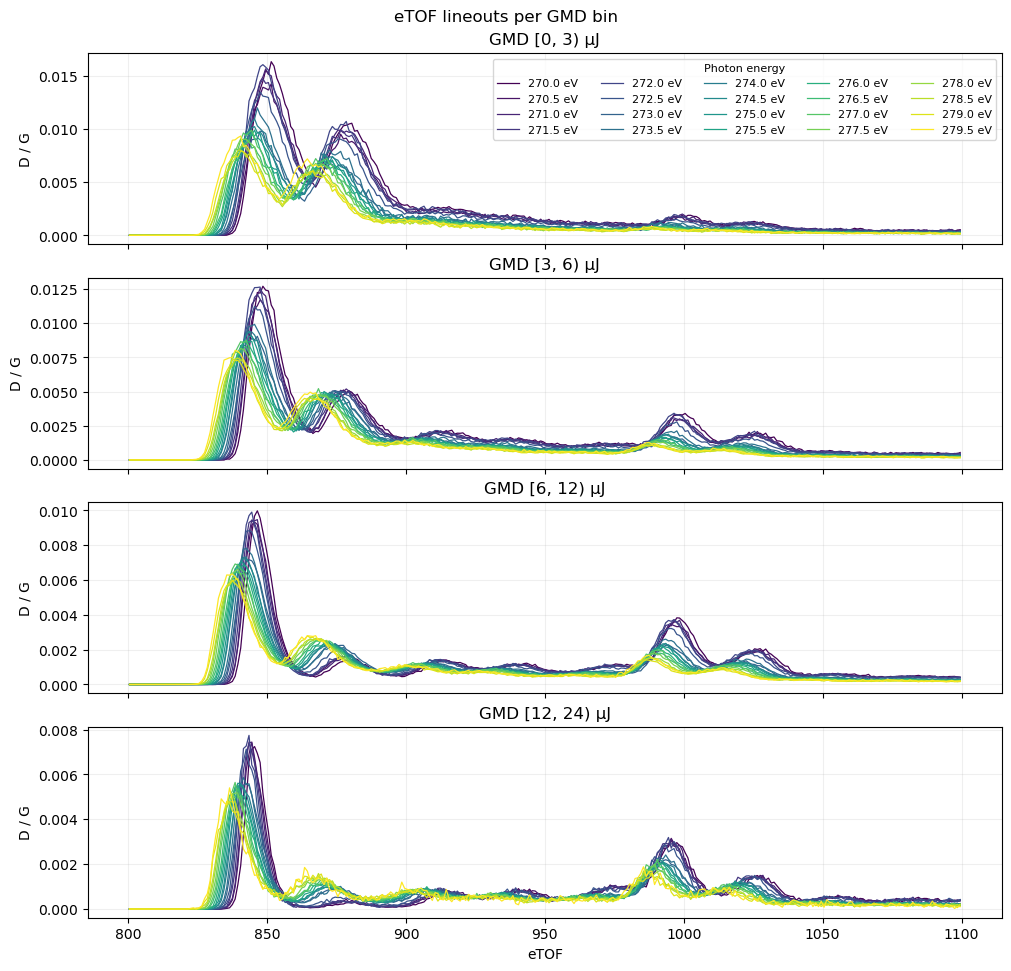

In [32]:
# --- Lineout plot: eTOF spectra per GMD bin -------------------------

ENERGIES_TO_PLOT = None
# Example if you want fewer curves:
# ENERGIES_TO_PLOT = [270.0, 272.0, 274.0, 276.0, 278.0, 279.5]

TOF_LINEOUT_RANGE = (800, 1100)

# Optional smoothing only for visual comparison.
# Set to 1 for no smoothing.
SMOOTH_BINS = 1
# SMOOTH_BINS = 5

def _smooth_1d(y, width):
    if width is None or width <= 1:
        return y
    kernel = np.ones(int(width), dtype=float) / float(width)
    return np.convolve(y, kernel, mode="same")

tof_cent = 0.5 * (tof_edges[:-1] + tof_edges[1:])

if ENERGIES_TO_PLOT is None:
    plot_idx = np.arange(len(energies))
else:
    plot_idx = []
    for e in ENERGIES_TO_PLOT:
        i = int(np.argmin(np.abs(energies - e)))
        if abs(energies[i] - e) > 1e-6:
            print(f"warning: requested {e} eV, using nearest {energies[i]} eV")
        plot_idx.append(i)
    plot_idx = np.array(plot_idx, dtype=int)

xmask = np.ones_like(tof_cent, dtype=bool)
if TOF_LINEOUT_RANGE[0] is not None:
    xmask &= tof_cent >= TOF_LINEOUT_RANGE[0]
if TOF_LINEOUT_RANGE[1] is not None:
    xmask &= tof_cent <= TOF_LINEOUT_RANGE[1]

fig, axes = plt.subplots(
    n_gmd, 1,
    figsize=(10, 2.4 * n_gmd),
    sharex=True,
    constrained_layout=True,
)
axes = np.atleast_1d(axes)

cmap = plt.get_cmap("viridis")
colors = cmap(np.linspace(0, 1, len(plot_idx)))

for g, ax in enumerate(axes):
    for c, i in zip(colors, plot_idx):
        y = stack[i, g, :]
        y = _smooth_1d(y, SMOOTH_BINS)
        ax.plot(
            tof_cent[xmask],
            y[xmask],
            lw=0.9,
            color=c,
            label=f"{energies[i]:.1f} eV",
        )

    ax.set_title(f"GMD [{gmd_edges[g]:.2g}, {gmd_edges[g + 1]:.2g}) µJ")
    ax.set_ylabel("D / G")
    ax.grid(alpha=0.2)

axes[-1].set_xlabel("eTOF")
axes[0].legend(
    title="Photon energy",
    ncols=min(5, len(plot_idx)),
    fontsize=8,
    title_fontsize=8,
    loc="upper right",
)

fig.suptitle("eTOF lineouts per GMD bin")
plt.show()

### Plot 2 — same map with the lowest GMD bin subtracted

At each energy we subtract the lowest GMD bin's normalised spectrum.
Per-shot intensity-independent signal (e.g. dark/background
electrons) cancels; what's left is the GMD-dependent contribution
above the low-fluence baseline.

The first panel is identically zero by construction.

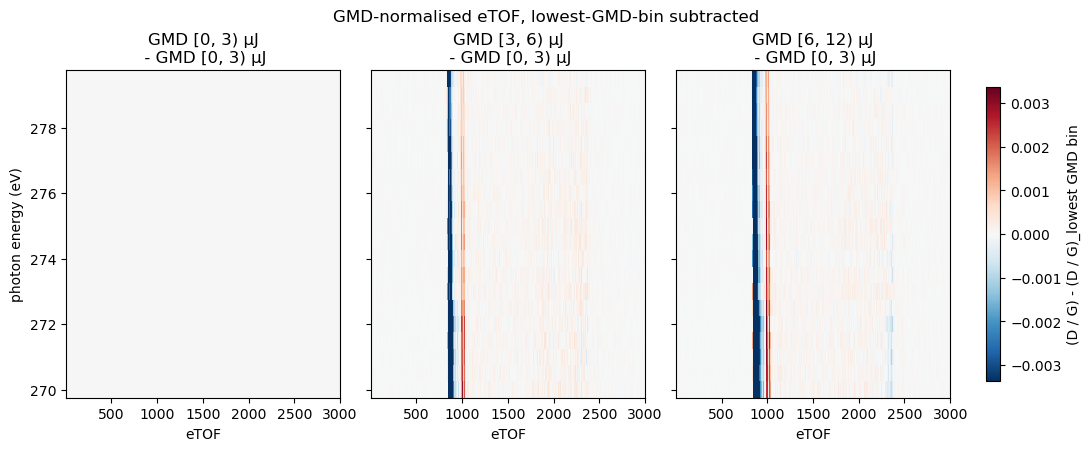

In [9]:
diff = stack - stack[:, 0:1, :]

if DIFF_SYM:
    lim = float(np.nanpercentile(np.abs(diff[np.isfinite(diff)]), 99))
    if lim <= 0:
        lim = float(np.nanmax(np.abs(diff))) or 1.0
    norm = TwoSlopeNorm(vmin=-lim, vcenter=0.0, vmax=lim)
    cmap = "RdBu_r"
else:
    norm = None
    cmap = "viridis"

fig, axes = plt.subplots(
    1, n_gmd, figsize=(3.6 * n_gmd, 4.4), sharey=True,
    constrained_layout=True,
)
axes = np.atleast_1d(axes)

for g, ax in enumerate(axes):
    pcm = ax.pcolormesh(
        tof_edges, e_edges, diff[:, g, :],
        cmap=cmap, norm=norm, shading="auto",
    )
    ax.set_title(
        f"GMD [{gmd_edges[g]:.2g}, {gmd_edges[g + 1]:.2g}) µJ\n"
        f" - GMD [{gmd_edges[0]:.2g}, {gmd_edges[1]:.2g}) µJ"
    )
    ax.set_xlabel("eTOF")
    if TOF_RANGE[0] is not None or TOF_RANGE[1] is not None:
        ax.set_xlim(TOF_RANGE[0], TOF_RANGE[1])

axes[0].set_ylabel("photon energy (eV)")
cbar = fig.colorbar(pcm, ax=axes, location="right", shrink=0.9, pad=0.02)
cbar.set_label("(D / G) - (D / G)_lowest GMD bin")
fig.suptitle("GMD-normalised eTOF, lowest-GMD-bin subtracted")
plt.show()